In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
import numpy as np 

from keras import layers
from keras import models
from keras import backend as K
from keras import callbacks
from keras import optimizers

In [2]:
data = pd.read_csv('TrainFile.csv')

In [3]:
# convert pd to np array
variablesTrain = ["Muon_InnerTrack_eta", "Muon_InnerTrack_phi", "Muon_InnerTrack_charge", "Muon_InnerTrack_pt", "Muon_DT_s1_nhits","Muon_DT_s1_x_mean","Muon_DT_s1_y_mean","Muon_DT_s1_z_mean","Muon_DT_s1_x_std","Muon_DT_s1_y_std","Muon_DT_s1_z_std","Muon_DT_s2_nhits","Muon_DT_s2_x_mean","Muon_DT_s2_y_mean","Muon_DT_s2_z_mean","Muon_DT_s2_x_std","Muon_DT_s2_y_std","Muon_DT_s2_z_std","Muon_DT_s3_nhits","Muon_DT_s3_x_mean","Muon_DT_s3_y_mean","Muon_DT_s3_z_mean","Muon_DT_s3_x_std","Muon_DT_s3_y_std","Muon_DT_s3_z_std","Muon_DT_s4_nhits","Muon_DT_s4_x_mean","Muon_DT_s4_y_mean","Muon_DT_s4_z_mean","Muon_DT_s4_x_std","Muon_DT_s4_y_std","Muon_DT_s4_z_std","Muon_CSC_s1_nhits","Muon_CSC_s1_x_mean","Muon_CSC_s1_y_mean","Muon_CSC_s1_z_mean","Muon_CSC_s1_x_std","Muon_CSC_s1_y_std","Muon_CSC_s1_z_std","Muon_CSC_s2_nhits","Muon_CSC_s2_x_mean","Muon_CSC_s2_y_mean","Muon_CSC_s2_z_mean","Muon_CSC_s2_x_std","Muon_CSC_s2_y_std","Muon_CSC_s2_z_std","Muon_CSC_s3_nhits","Muon_CSC_s3_x_mean","Muon_CSC_s3_y_mean","Muon_CSC_s3_z_mean","Muon_CSC_s3_x_std","Muon_CSC_s3_y_std","Muon_CSC_s3_z_std","Muon_CSC_s4_nhits","Muon_CSC_s4_x_mean","Muon_CSC_s4_y_mean","Muon_CSC_s4_z_mean","Muon_CSC_s4_x_std","Muon_CSC_s4_y_std","Muon_CSC_s4_z_std"]
genpT = ["Muon_Genpt"]
train, test = train_test_split(data, test_size=0.2)


In [90]:
K.clear_session()

model = models.Sequential()

model.add(layers.Dense(512, activation='relu', input_dim=len(variablesTrain)))
model.add(layers.Dense(512, activation='relu'))
model.add(layers.Dense(256, activation='relu'))
model.add(layers.Dense(256, activation='relu'))
model.add(layers.Dense(128, activation='relu'))
model.add(layers.Dense(128, activation='relu'))
model.add(layers.Dense(64, activation='relu'))
model.add(layers.Dense(64, activation='relu'))
model.add(layers.Dense(16, activation='relu'))
model.add(layers.Dense(1, activation='linear'))
model.summary()

opt = optimizers.Adam(0.00005)
model.compile(loss="mean_squared_error", optimizer=opt)

_________________________________________________________________
Layer (type)                 Output Shape              Param #   
dense_1 (Dense)              (None, 512)               31232     
_________________________________________________________________
dense_2 (Dense)              (None, 512)               262656    
_________________________________________________________________
dense_3 (Dense)              (None, 256)               131328    
_________________________________________________________________
dense_4 (Dense)              (None, 256)               65792     
_________________________________________________________________
dense_5 (Dense)              (None, 128)               32896     
_________________________________________________________________
dense_6 (Dense)              (None, 128)               16512     
_________________________________________________________________
dense_7 (Dense)              (None, 64)                8256      
__________

In [91]:
history = model.fit(train[variablesTrain],train[genpT],validation_split=0.1, epochs=1000, batch_size=2000, verbose=1, callbacks=[callbacks.EarlyStopping(monitor='val_loss',patience=50,verbose=1)])

Train on 90259 samples, validate on 10029 samples
Epoch 1/1000
90259/90259 [==============================] - 5s 56us/step - loss: 2003182.2332 - val_loss: 1748206.1242
Epoch 2/1000
90259/90259 [==============================] - 3s 32us/step - loss: 2656012.8701 - val_loss: 1772827.0631
Epoch 3/1000
90259/90259 [==============================] - 3s 33us/step - loss: 1642338.5262 - val_loss: 1343468.7192
Epoch 4/1000
90259/90259 [==============================] - 3s 36us/step - loss: 1587998.1014 - val_loss: 1088178.7420
Epoch 5/1000
90259/90259 [==============================] - 3s 37us/step - loss: 1464205.3686 - val_loss: 936719.4129
Epoch 6/1000
90259/90259 [==============================] - 3s 37us/step - loss: 769582.3020 - val_loss: 612311.0466
Epoch 7/1000
90259/90259 [==============================] - 3s 37us/step - loss: 491330.1963 - val_loss: 275736.9056
Epoch 8/1000
90259/90259 [==============================] - 3s 36us/step - loss: 192836.8611 - val_loss: 124066.7194
Epoch

90259/90259 [==============================] - 4s 43us/step - loss: 52997.6304 - val_loss: 59784.1775
Epoch 72/1000
90259/90259 [==============================] - 4s 42us/step - loss: 52347.9323 - val_loss: 54807.6597
Epoch 73/1000
90259/90259 [==============================] - 4s 49us/step - loss: 50901.0890 - val_loss: 53808.2972
Epoch 74/1000
90259/90259 [==============================] - 4s 46us/step - loss: 50467.8138 - val_loss: 54352.0224
Epoch 75/1000
90259/90259 [==============================] - 4s 45us/step - loss: 50034.3749 - val_loss: 54920.6625
Epoch 76/1000
90259/90259 [==============================] - 5s 50us/step - loss: 49502.2995 - val_loss: 51931.1055
Epoch 77/1000
90259/90259 [==============================] - 4s 47us/step - loss: 49264.8239 - val_loss: 53720.9082
Epoch 78/1000
90259/90259 [==============================] - 4s 45us/step - loss: 49333.9803 - val_loss: 58861.3843
Epoch 79/1000
90259/90259 [==============================] - 4s 43us/step - loss: 5123

90259/90259 [==============================] - 3s 38us/step - loss: 48528.2890 - val_loss: 50438.1345
Epoch 142/1000
90259/90259 [==============================] - 4s 39us/step - loss: 49066.2966 - val_loss: 56080.8295
Epoch 143/1000
90259/90259 [==============================] - 4s 39us/step - loss: 47901.0686 - val_loss: 49499.4230
Epoch 144/1000
90259/90259 [==============================] - 4s 39us/step - loss: 47593.2441 - val_loss: 50876.5677
Epoch 145/1000
90259/90259 [==============================] - 3s 38us/step - loss: 52502.2225 - val_loss: 63939.4501
Epoch 146/1000
90259/90259 [==============================] - 4s 39us/step - loss: 51715.1689 - val_loss: 54642.7969
Epoch 147/1000
90259/90259 [==============================] - 4s 39us/step - loss: 51738.9703 - val_loss: 56844.9628
Epoch 148/1000
90259/90259 [==============================] - 4s 40us/step - loss: 49654.7218 - val_loss: 54715.7037
Epoch 149/1000
90259/90259 [==============================] - 3s 39us/step - lo

90259/90259 [==============================] - 4s 39us/step - loss: 62011.5291 - val_loss: 55363.0297
Epoch 212/1000
90259/90259 [==============================] - 3s 38us/step - loss: 46540.9585 - val_loss: 51856.8196
Epoch 213/1000
90259/90259 [==============================] - 4s 40us/step - loss: 47128.8217 - val_loss: 56182.3720
Epoch 214/1000
90259/90259 [==============================] - 4s 39us/step - loss: 46572.4609 - val_loss: 52708.6482
Epoch 215/1000
90259/90259 [==============================] - 4s 39us/step - loss: 45646.7805 - val_loss: 52075.5202
Epoch 216/1000
90259/90259 [==============================] - 3s 38us/step - loss: 45461.3659 - val_loss: 52840.1007
Epoch 217/1000
90259/90259 [==============================] - 4s 39us/step - loss: 45138.8275 - val_loss: 49208.3221
Epoch 218/1000
90259/90259 [==============================] - 4s 39us/step - loss: 48142.6255 - val_loss: 54099.7816
Epoch 219/1000
90259/90259 [==============================] - 4s 40us/step - lo

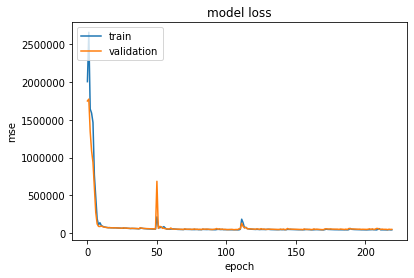

In [92]:
import matplotlib.pyplot as plt

# summarize history for loss
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('model loss')
plt.ylabel('mse')
plt.xlabel('epoch')
plt.legend(['train', 'validation'], loc='upper left')
plt.show()

In [93]:
results = model.evaluate(test[variablesTrain], test[genpT], batch_size=128)
print('test loss:', results)


25073/25073 [==============================] - 1s 35us/step
test loss: 51586.08423263446


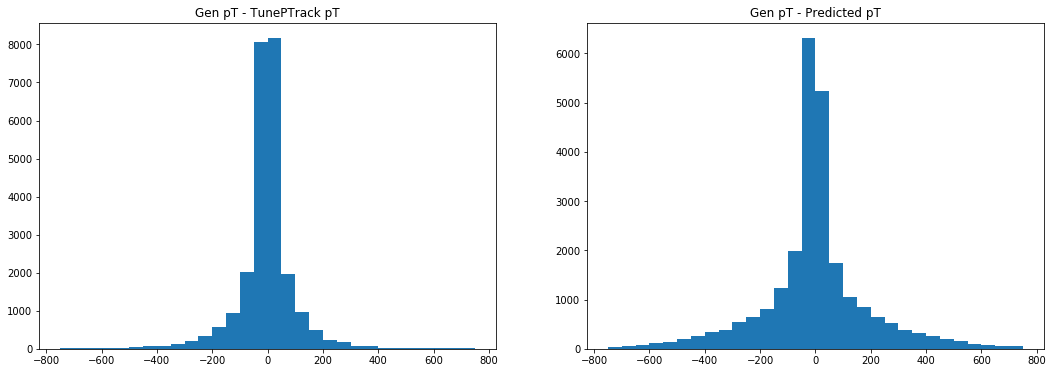

In [94]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(18, 6))


axes[0].hist(test.Muon_Genpt.values-test.Muon_TunePTrack_pt.values, bins = 30, range=(-750,750)) 
axes[0].set_title("Gen pT - TunePTrack pT") 
axes[1].hist(test.Muon_Genpt.values-model.predict(test[variablesTrain]).ravel(), bins = 30, range=(-750,750)) 
axes[1].set_title("Gen pT - Predicted pT") 
plt.show()

### Selecting Muons with nHits > 6 (50387/125361)

In [110]:
data_gt_6 = data[data.Muon_nHits>6]

In [111]:
train_gt_6, test_gt_6 = train_test_split(data_gt_6, test_size=0.1)

In [112]:
K.clear_session()

model = models.Sequential()

model.add(layers.Dense(512, activation='relu', input_dim=len(variablesTrain)))
model.add(layers.Dense(512, activation='relu'))
model.add(layers.Dense(256, activation='relu'))
model.add(layers.Dense(256, activation='relu'))
model.add(layers.Dense(128, activation='relu'))
model.add(layers.Dense(128, activation='relu'))
model.add(layers.Dense(64, activation='relu'))
model.add(layers.Dense(64, activation='relu'))
model.add(layers.Dense(16, activation='relu'))
model.add(layers.Dense(1, activation='linear'))
model.summary()

opt = optimizers.Adam(0.00005)
model.compile(loss="mean_squared_error", optimizer=opt)

_________________________________________________________________
Layer (type)                 Output Shape              Param #   
dense_1 (Dense)              (None, 512)               31232     
_________________________________________________________________
dense_2 (Dense)              (None, 512)               262656    
_________________________________________________________________
dense_3 (Dense)              (None, 256)               131328    
_________________________________________________________________
dense_4 (Dense)              (None, 256)               65792     
_________________________________________________________________
dense_5 (Dense)              (None, 128)               32896     
_________________________________________________________________
dense_6 (Dense)              (None, 128)               16512     
_________________________________________________________________
dense_7 (Dense)              (None, 64)                8256      
__________

In [113]:
history = model.fit(train_gt_6[variablesTrain],train_gt_6[genpT],validation_split=0.1, epochs=1000, batch_size=2000, verbose=1, callbacks=[callbacks.EarlyStopping(monitor='val_loss',patience=50,verbose=1)])

Train on 40813 samples, validate on 4535 samples
Epoch 1/1000
40813/40813 [==============================] - 4s 88us/step - loss: 1872356.5423 - val_loss: 1748970.9181
Epoch 2/1000
40813/40813 [==============================] - 1s 36us/step - loss: 1809367.3098 - val_loss: 1673400.5532
Epoch 3/1000
40813/40813 [==============================] - 1s 35us/step - loss: 1709916.0858 - val_loss: 1601828.1384
Epoch 4/1000
40813/40813 [==============================] - 1s 34us/step - loss: 1582631.3584 - val_loss: 1389137.8473
Epoch 5/1000
40813/40813 [==============================] - 1s 35us/step - loss: 2029987.1207 - val_loss: 1279084.8600
Epoch 6/1000
40813/40813 [==============================] - 1s 36us/step - loss: 1153204.6233 - val_loss: 1066101.6783
Epoch 7/1000
40813/40813 [==============================] - 2s 39us/step - loss: 1043835.0709 - val_loss: 891213.4423
Epoch 8/1000
40813/40813 [==============================] - 2s 38us/step - loss: 927504.1431 - val_loss: 772422.7707
Ep

Epoch 71/1000
40813/40813 [==============================] - 2s 44us/step - loss: 59492.2423 - val_loss: 67250.2911
Epoch 72/1000
40813/40813 [==============================] - 2s 44us/step - loss: 62460.7625 - val_loss: 66980.0475
Epoch 73/1000
40813/40813 [==============================] - 2s 45us/step - loss: 60649.2336 - val_loss: 62661.0924
Epoch 74/1000
40813/40813 [==============================] - 2s 45us/step - loss: 59110.9415 - val_loss: 61978.6383
Epoch 75/1000
40813/40813 [==============================] - 2s 47us/step - loss: 58977.5701 - val_loss: 61615.8504
Epoch 76/1000
40813/40813 [==============================] - 2s 45us/step - loss: 61938.0340 - val_loss: 70149.2078
Epoch 77/1000
40813/40813 [==============================] - 2s 44us/step - loss: 62401.1085 - val_loss: 66381.3999
Epoch 78/1000
40813/40813 [==============================] - 2s 45us/step - loss: 60074.6186 - val_loss: 63770.5060
Epoch 79/1000
40813/40813 [==============================] - 2s 44us/ste

40813/40813 [==============================] - 2s 45us/step - loss: 56893.3014 - val_loss: 60779.2020
Epoch 142/1000
40813/40813 [==============================] - 2s 42us/step - loss: 54539.7178 - val_loss: 62680.1447
Epoch 143/1000
40813/40813 [==============================] - 2s 43us/step - loss: 56358.2691 - val_loss: 67462.2190
Epoch 144/1000
40813/40813 [==============================] - 2s 43us/step - loss: 66129.3404 - val_loss: 69083.2191
Epoch 145/1000
40813/40813 [==============================] - 2s 41us/step - loss: 61722.6048 - val_loss: 66389.4586
Epoch 146/1000
40813/40813 [==============================] - 2s 41us/step - loss: 58606.4599 - val_loss: 64317.8862
Epoch 147/1000
40813/40813 [==============================] - 2s 41us/step - loss: 56123.7351 - val_loss: 61592.1358
Epoch 148/1000
40813/40813 [==============================] - 2s 40us/step - loss: 56164.4936 - val_loss: 63460.7380
Epoch 149/1000
40813/40813 [==============================] - 2s 40us/step - lo

Epoch 211/1000
40813/40813 [==============================] - 2s 44us/step - loss: 51731.9189 - val_loss: 59464.4716
Epoch 212/1000
40813/40813 [==============================] - 2s 44us/step - loss: 51722.5249 - val_loss: 59802.9783
Epoch 213/1000
40813/40813 [==============================] - 2s 45us/step - loss: 50893.3981 - val_loss: 61048.8826
Epoch 214/1000
40813/40813 [==============================] - 2s 44us/step - loss: 51139.1324 - val_loss: 60122.2052
Epoch 215/1000
40813/40813 [==============================] - 2s 43us/step - loss: 51177.8802 - val_loss: 59059.4110
Epoch 216/1000
40813/40813 [==============================] - 2s 42us/step - loss: 50568.9703 - val_loss: 59470.7750
Epoch 217/1000
40813/40813 [==============================] - 2s 43us/step - loss: 50606.5977 - val_loss: 62752.1758
Epoch 218/1000
40813/40813 [==============================] - 2s 43us/step - loss: 51031.6772 - val_loss: 59304.5591
Epoch 219/1000
40813/40813 [==============================] - 2s

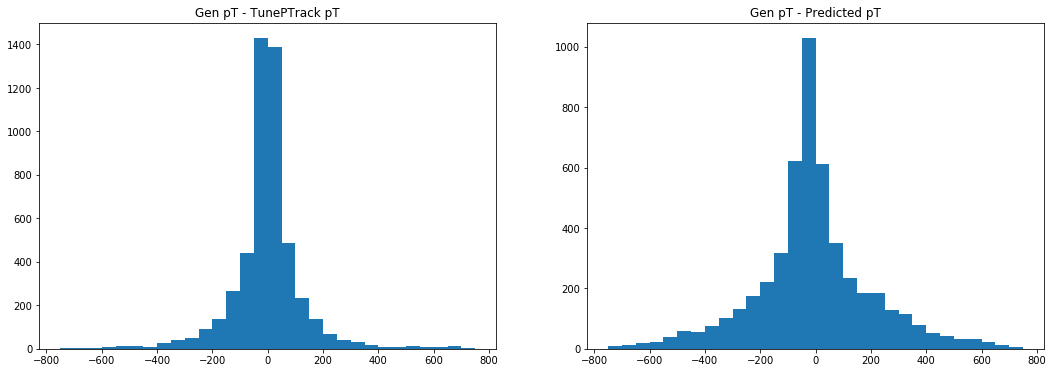

In [115]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(18, 6))


axes[0].hist(test_gt_6.Muon_Genpt.values-test_gt_6.Muon_TunePTrack_pt.values, bins = 30, range=(-750,750)) 
axes[0].set_title("Gen pT - TunePTrack pT") 
axes[1].hist(test_gt_6.Muon_Genpt.values-model.predict(test_gt_6[variablesTrain]).ravel(), bins = 30, range=(-750,750)) 
axes[1].set_title("Gen pT - Predicted pT") 
plt.show()

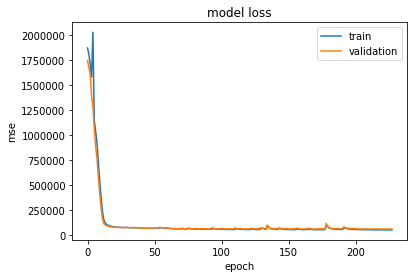

In [122]:
# summarize history for loss
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('model loss')
plt.ylabel('mse')
plt.xlabel('epoch')
plt.legend(['train', 'validation'], loc='upper right')
plt.show()